In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_dir = Path.cwd()
if not (project_dir / 'data_fifa.xlsx').exists() and (project_dir.parent / 'data_fifa.xlsx').exists():
    project_dir = project_dir.parent

broadcast_dir = project_dir / 'broadcast'

df_games = pd.read_excel(project_dir / 'data_fifa.xlsx', sheet_name='games')
df_tz = pd.read_excel(project_dir / 'data_fifa.xlsx', sheet_name='country_TZ')
df_weights = pd.read_csv(broadcast_dir / 'betting_team_probabilities_with_interest.csv')


In [5]:
from dataclasses import dataclass
@dataclass
class Team:
    country: str          # canonical label used in the output
    geo: str              # Google Trends geo code (ISO-3166 country), e.g. "FR"
    wiki_project: str     # Wikipedia language edition, e.g. "fr.wikipedia.org"
    wiki_article: str     # exact (canonical) national-team article title
    population: float     # population in millions (2026 estimate)
TEAMS = [
    # Hosts
    Team("United States",          "US", "en.wikipedia.org", "United States men's national soccer team", 340.0),
    Team("Mexico",                 "MX", "en.wikipedia.org", "Mexico national football team", 128.0),
    Team("Canada",                 "CA", "en.wikipedia.org", "Canada men's national soccer team", 40.0),
    # UEFA
    Team("England",                "GB", "en.wikipedia.org", "England national football team", 57.0),
    Team("France",                 "FR", "en.wikipedia.org", "France national football team", 67.0),
    Team("Croatia",                "HR", "en.wikipedia.org", "Croatia national football team", 4.0),
    Team("Norway",                 "NO", "en.wikipedia.org", "Norway national football team", 5.5),
    Team("Portugal",               "PT", "en.wikipedia.org", "Portugal national football team", 10.5),
    Team("Germany",                "DE", "en.wikipedia.org", "Germany national football team", 84.0),
    Team("Netherlands",            "NL", "en.wikipedia.org", "Netherlands national football team", 17.5),
    Team("Switzerland",            "CH", "en.wikipedia.org", "Switzerland national football team", 8.7),
    Team("Scotland",               "GB", "en.wikipedia.org", "Scotland national football team", 5.5),
    Team("Spain",                  "ES", "en.wikipedia.org", "Spain national football team", 48.0),
    Team("Austria",                "AT", "en.wikipedia.org", "Austria national football team", 9.0),
    Team("Belgium",                "BE", "en.wikipedia.org", "Belgium national football team", 11.5),
    Team("Bosnia and Herzegovina", "BA", "en.wikipedia.org", "Bosnia and Herzegovina national football team", 3.3),
    Team("Sweden",                 "SE", "en.wikipedia.org", "Sweden national football team", 10.5),
    Team("Turkey",                 "TR", "en.wikipedia.org", "Turkey national football team", 86.0),
    Team("Czechia",                "CZ", "en.wikipedia.org", "Czech Republic national football team", 10.5),
    # CONCACAF (besides hosts)
    Team("Panama",                 "PA", "en.wikipedia.org", "Panama national football team", 4.4),
    Team("Curaçao",                "CW", "en.wikipedia.org", "Curaçao national football team", 0.155),
    Team("Haiti",                  "HT", "en.wikipedia.org", "Haiti national football team", 11.4),
    # CAF
    Team("Algeria",                "DZ", "en.wikipedia.org", "Algeria national football team", 44.0),
    Team("Cape Verde",             "CV", "en.wikipedia.org", "Cape Verde national football team", 0.58),
    Team("Egypt",                  "EG", "en.wikipedia.org", "Egypt national football team", 106.0),
    Team("Ghana",                  "GH", "en.wikipedia.org", "Ghana national football team", 34.0),
    Team("Ivory Coast",            "CI", "en.wikipedia.org", "Ivory Coast national football team", 28.0),
    Team("Morocco",                "MA", "en.wikipedia.org", "Morocco national football team", 37.0),
    Team("Senegal",                "SN", "en.wikipedia.org", "Senegal national football team", 17.5),
    Team("South Africa",           "ZA", "en.wikipedia.org", "South Africa national football team", 60.0),
    Team("Tunisia",                "TN", "en.wikipedia.org", "Tunisia national football team", 12.0),
    # AFC
    Team("Australia",              "AU", "en.wikipedia.org", "Australia men's national soccer team", 26.0),
    Team("Iran",                   "IR", "en.wikipedia.org", "Iran national football team", 91.0),
    Team("Japan",                  "JP", "en.wikipedia.org", "Japan national football team", 125.0),
    Team("Jordan",                 "JO", "en.wikipedia.org", "Jordan national football team", 10.0),
    Team("Uzbekistan",             "UZ", "en.wikipedia.org", "Uzbekistan national football team", 34.0),
    Team("Qatar",                  "QA", "en.wikipedia.org", "Qatar national football team", 3.2),
    Team("Saudi Arabia",           "SA", "en.wikipedia.org", "Saudi Arabia national football team", 36.0),
    Team("South Korea",            "KR", "en.wikipedia.org", "South Korea national football team", 51.0),
    # CONMEBOL
    Team("Argentina",              "AR", "en.wikipedia.org", "Argentina national football team", 47.0),
    Team("Brazil",                 "BR", "en.wikipedia.org", "Brazil national football team", 215.0),
    Team("Colombia",               "CO", "en.wikipedia.org", "Colombia national football team", 52.0),
    Team("Ecuador",                "EC", "en.wikipedia.org", "Ecuador national football team", 18.5),
    Team("Paraguay",               "PY", "en.wikipedia.org", "Paraguay national football team", 7.0),
    Team("Uruguay",                "UY", "en.wikipedia.org", "Uruguay national football team", 3.4),
    # OFC
    Team("New Zealand",            "NZ", "en.wikipedia.org", "New Zealand national football team", 5.2),
    # Inter-confederation playoff winners
    Team("DR Congo",               "CD", "en.wikipedia.org", "DR Congo national football team", 99.0),
    Team("Iraq",                   "IQ", "en.wikipedia.org", "Iraq national football team", 43.0),
]


In [ ]:
def time_to_float(value):
    """Convert 'HH:MM' values to decimal hours."""
    if pd.isna(value):
        return pd.NA
    if isinstance(value, str):
        hours, minutes = map(int, value.split(':'))
        return hours + minutes / 60
    return float(value)

name_map_to_odds = {
    'Bosnia and Herzegovina': 'Bosnia & Herzegovina',
    'Czechia': 'Czech Republic',
    'Korea Republic': 'South Korea',
    'Türkiye': 'Turkey',
}

df_games['local_time'] = df_games['local_time'].apply(time_to_float)
team_tz = df_tz.set_index('Country')['UTC']

df_games['team_1_localtime'] = (
    df_games['local_time'] + df_games['team_1'].map(team_tz) - df_games['UTC_Offset']
) % 24

df_games['team_2_localtime'] = (
    df_games['local_time'] + df_games['team_2'].map(team_tz) - df_games['UTC_Offset']
) % 24


In [7]:
team_1_rows = df_games.assign(
    side='team_1',
    country=df_games['team_1'],
    opponent=df_games['team_2'],
    localtime=df_games['team_1_localtime'],
)

team_2_rows = df_games.assign(
    side='team_2',
    country=df_games['team_2'],
    opponent=df_games['team_1'],
    localtime=df_games['team_2_localtime'],
)

df_country_game = pd.concat([team_1_rows, team_2_rows], ignore_index=True)
df_country_game = df_country_game.drop(columns=['team_1', 'team_2', 'team_1_localtime', 'team_2_localtime'])

df_country_game['country_odds'] = df_country_game['country'].replace(name_map_to_odds)
df_country_game['opponent_odds'] = df_country_game['opponent'].replace(name_map_to_odds)

df_weighted_country_game = df_country_game.merge(
    df_weights[['country', 'opponent', 'p_win', 'closeness', 'trends_interest_per_capita', 'game_weight_for_country']],
    left_on=['country_odds', 'opponent_odds'],
    right_on=['country', 'opponent'],
    how='left',
    suffixes=('', '_weighted'),
)

missing_weights = df_weighted_country_game[df_weighted_country_game['game_weight_for_country'].isna()]
print(f'Rows: {len(df_weighted_country_game)}')
print(f'Missing weights: {len(missing_weights)}')

df_weighted_country_game.head()


Rows: 144
Missing weights: 0


,#match,group,date,local_time,stadium,city,country,day,UTC_Offset,side,opponent,localtime,country_odds,opponent_odds,country_weighted,opponent_weighted,p_win,closeness,trends_interest_per_capita,game_weight_for_country
0,25,A,2026-06-18,12.0,Mercedes-Benz Stadium,Atlanta,Czechia,2,-4,team_1,South Africa,17.0,Czech Republic,South Africa,Czech Republic,South Africa,0.466298,0.962735,63000000.0,606.522987
1,2,A,2026-06-11,22.0,Estadio Akron,Guadalajara,Korea Republic,1,-6,team_1,Czechia,13.0,South Korea,Czech Republic,South Korea,Czech Republic,0.353514,0.997462,459000000.0,4578.349655
2,52,C,2026-06-24,18.0,Mercedes-Benz Stadium,Atlanta,Morocco,3,-4,team_1,Haiti,23.0,Morocco,Haiti,Morocco,Haiti,0.708455,0.723688,333000000.0,2409.879619
3,28,A,2026-06-18,21.0,Estadio Akron,Guadalajara,Mexico,2,-6,team_1,Korea Republic,21.0,Mexico,South Korea,Mexico,South Korea,0.519687,0.928938,896000000.0,8323.285319
4,13,H,2026-06-15,12.0,Mercedes-Benz Stadium,Atlanta,Spain,1,-4,team_1,Cape Verde,17.0,Spain,Cape Verde,Spain,Cape Verde,0.876013,0.407398,240000000.0,977.754188


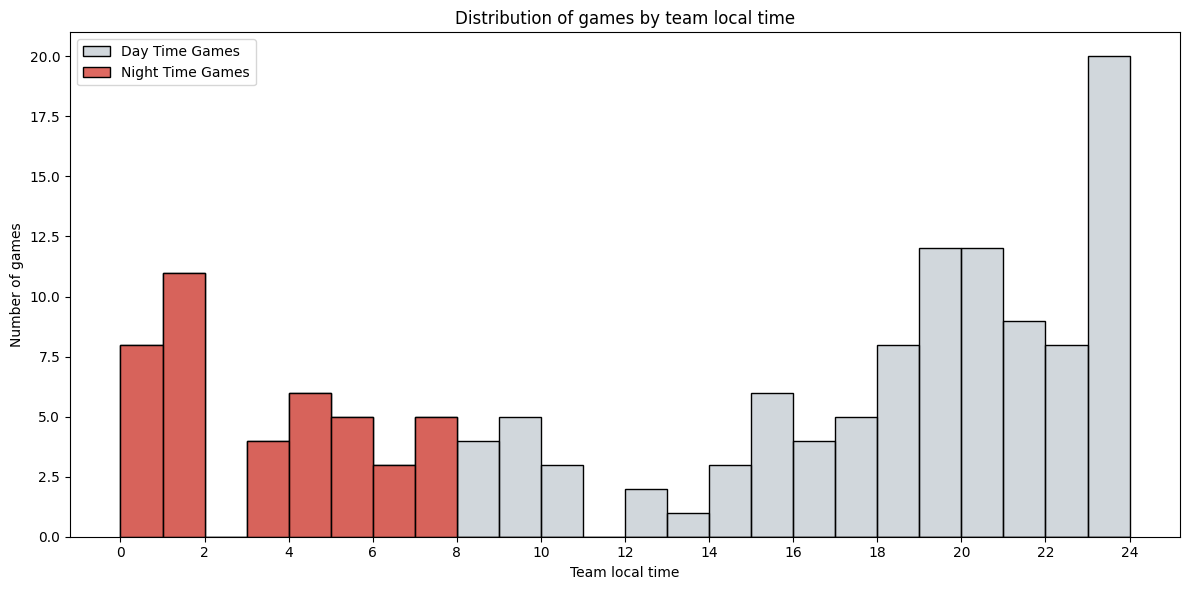

In [14]:
plt.figure(figsize=(12, 6))
bins = range(25)
sns.histplot(df_country_game['localtime'], bins=bins, color='#9aa7b2', alpha=0.45, label='Day Time Games')
sns.histplot(df_country_game.loc[df_country_game['localtime'] < 8, 'localtime'], bins=bins, color='#d94f45', alpha=0.85, label='Night Time Games')
plt.xlabel('Team local time')
plt.ylabel('Number of games')
plt.title('Distribution of games by team local time')
plt.xticks(range(0, 25, 2))
plt.legend()
plt.tight_layout()
plt.show()


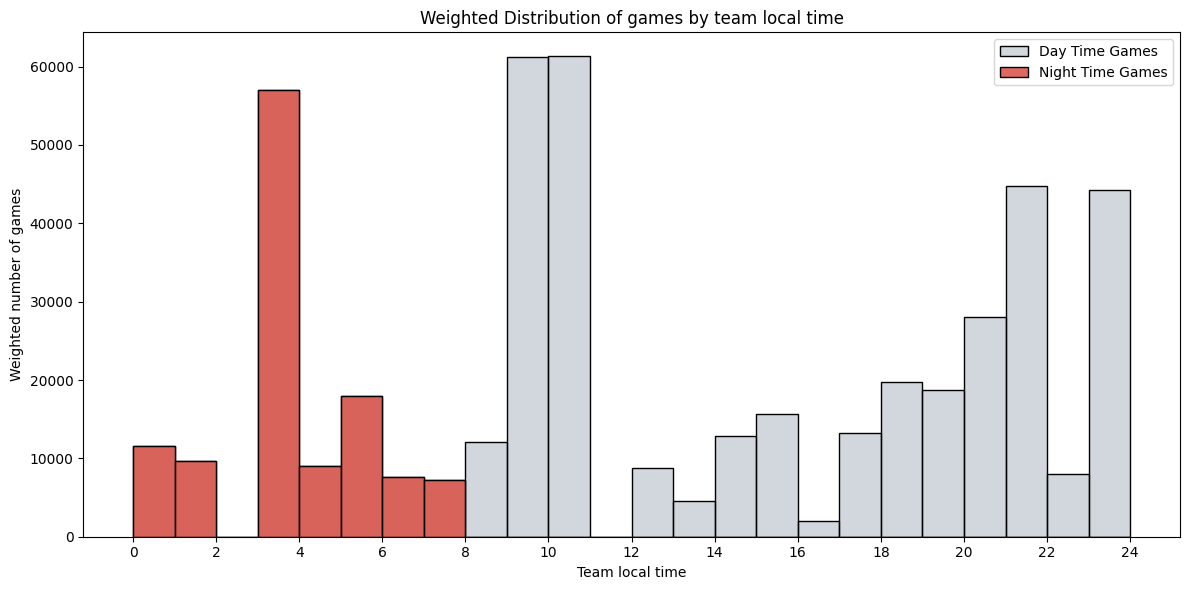

In [15]:
plt.figure(figsize=(12, 6))
bins = range(25)
sns.histplot(
    data=df_weighted_country_game,
    x='localtime',
    weights='game_weight_for_country',
    bins=bins,
    color='#9aa7b2',
    alpha=0.45,
    label='Day Time Games',
)
sns.histplot(
    data=df_weighted_country_game.loc[df_weighted_country_game['localtime'] < 8],
    x='localtime',
    weights='game_weight_for_country',
    bins=bins,
    color='#d94f45',
    alpha=0.85,
    label='Night Time Games',
)
plt.xlabel('Team local time')
plt.ylabel('Weighted number of games')
plt.title('Weighted Distribution of games by team local time')
plt.xticks(range(0, 25, 2))
plt.legend()
plt.tight_layout()
plt.show()


Missing population weights: 0


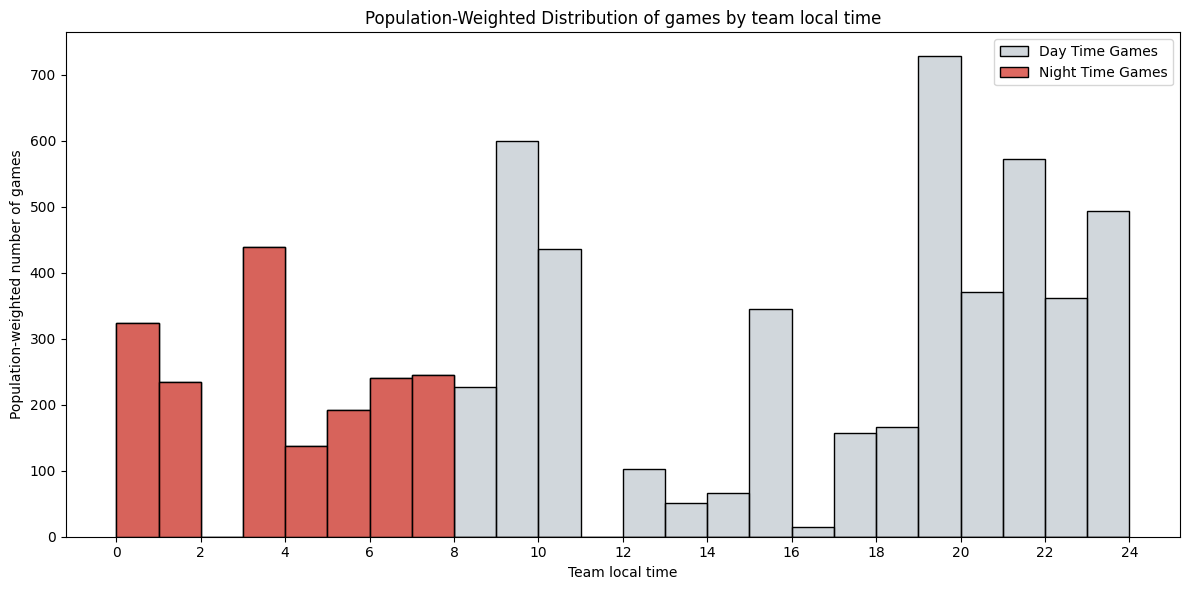

In [16]:
population_by_country = {team.country: team.population for team in TEAMS}
population_aliases = {
    'USA': 'United States',
    'Korea Republic': 'South Korea',
    'Türkiye': 'Turkey',
    'Czech Republic': 'Czechia',
    'Bosnia & Herzegovina': 'Bosnia and Herzegovina',
}

df_population_country_game = df_country_game.copy()
df_population_country_game['population_weight'] = (
    df_population_country_game['country']
    .replace(population_aliases)
    .map(population_by_country)
)

missing_population = df_population_country_game[df_population_country_game['population_weight'].isna()]
print(f'Missing population weights: {len(missing_population)}')

plt.figure(figsize=(12, 6))
bins = range(25)
sns.histplot(
    data=df_population_country_game,
    x='localtime',
    weights='population_weight',
    bins=bins,
    color='#9aa7b2',
    alpha=0.45,
    label='Day Time Games',
)
sns.histplot(
    data=df_population_country_game.loc[df_population_country_game['localtime'] < 8],
    x='localtime',
    weights='population_weight',
    bins=bins,
    color='#d94f45',
    alpha=0.85,
    label='Night Time Games',
)
plt.xlabel('Team local time')
plt.ylabel('Population-weighted number of games')
plt.title('Population-Weighted Distribution of games by team local time')
plt.xticks(range(0, 25, 2))
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
population_by_country = {team.country: team.population for team in TEAMS}
population_aliases = {
    'USA': 'United States',
    'Korea Republic': 'South Korea',
    'Türkiye': 'Turkey',
    'Czech Republic': 'Czechia',
    'Bosnia & Herzegovina': 'Bosnia and Herzegovina',
}

df_population_country_game = df_country_game.copy()
df_population_country_game['country_population_label'] = (
    df_population_country_game['country'].replace(population_aliases)
)
df_population_country_game['population_weight'] = (
    df_population_country_game['country_population_label'].map(population_by_country)
)

early_unweighted_top10 = (
    df_country_game.loc[df_country_game['localtime'] < 8]
    .groupby('country_odds', as_index=False)
    .agg(early_games=('localtime', 'count'))
    .rename(columns={'country_odds': 'country'})
    .assign(ranking='No weight', base_weight=1, score=lambda df: df['early_games'])
    .sort_values('score', ascending=False)
    .head(10)
)

early_weighted_top10 = (
    df_weighted_country_game.loc[df_weighted_country_game['localtime'] < 8]
    .groupby('country_odds', as_index=False)
    .agg(
        early_games=('localtime', 'count'),
        base_weight=('game_weight_for_country', 'mean'),
    )
    .rename(columns={'country_odds': 'country'})
    .assign(ranking='Weight', score=lambda df: df['base_weight'] * df['early_games'])
    .sort_values('score', ascending=False)
    .head(10)
)

early_population_top10 = (
    df_population_country_game.loc[df_population_country_game['localtime'] < 8]
    .groupby('country_population_label', as_index=False)
    .agg(
        early_games=('localtime', 'count'),
        base_weight=('population_weight', 'first'),
    )
    .rename(columns={'country_population_label': 'country'})
    .assign(ranking='Weight by population', score=lambda df: df['base_weight'] * df['early_games'])
    .sort_values('score', ascending=False)
    .head(10)
)

early_localtime_top10 = (
    pd.concat([early_unweighted_top10, early_weighted_top10, early_population_top10], ignore_index=True)
    .assign(rank=lambda df: df.groupby('ranking').cumcount() + 1)
    [['ranking', 'rank', 'country', 'early_games', 'base_weight', 'score']]
)

early_localtime_top10


,ranking,rank,country,early_games,base_weight,score
0,No weight,1,Algeria,3,1.000000,3.000000
1,No weight,2,Tunisia,3,1.000000,3.000000
2,No weight,3,Paraguay,3,1.000000,3.000000
3,No weight,4,Qatar,3,1.000000,3.000000
4,No weight,5,Sweden,2,1.000000,2.000000
5,No weight,6,Czech Republic,2,1.000000,2.000000
6,No weight,7,DR Congo,2,1.000000,2.000000
7,No weight,8,Saudi Arabia,2,1.000000,2.000000
8,No weight,9,Iran,2,1.000000,2.000000
9,No weight,10,Iraq,2,1.000000,2.000000


In [23]:
population_by_country = {team.country: team.population for team in TEAMS}
population_aliases = {
    'USA': 'United States',
    'Korea Republic': 'South Korea',
    'Türkiye': 'Turkey',
    'Czech Republic': 'Czechia',
    'Bosnia & Herzegovina': 'Bosnia and Herzegovina',
}

country_base = (
    df_country_game[['country_odds', 'country']]
    .drop_duplicates('country_odds')
    .rename(columns={'country_odds': 'country_display'})
)
country_base['country_population_label'] = country_base['country'].replace(population_aliases)
country_base['population_weight'] = country_base['country_population_label'].map(population_by_country)

early_game_counts = (
    df_country_game.loc[df_country_game['localtime'] < 8]
    .groupby('country_odds', as_index=False)
    .size()
    .rename(columns={'country_odds': 'country_display', 'size': 'early_games'})
)

early_weight_scores = (
    df_weighted_country_game.loc[df_weighted_country_game['localtime'] < 8]
    .groupby('country_odds', as_index=False)
    .agg(weighted_score=('game_weight_for_country', 'sum'))
    .rename(columns={'country_odds': 'country_display'})
)

early_ranking_table = (
    country_base
    .merge(early_game_counts, on='country_display', how='left')
    .merge(early_weight_scores, on='country_display', how='left')
    .fillna({'early_games': 0, 'weighted_score': 0})
)
early_ranking_table['early_games'] = early_ranking_table['early_games'].astype(int)
has_early_games = early_ranking_table['early_games'] > 0
early_ranking_table['population_score'] = (
    early_ranking_table['population_weight'].where(has_early_games, 0)
    * early_ranking_table['early_games']
)
early_ranking_table['weighted_score'] = (
    early_ranking_table['weighted_score'].where(has_early_games, 0)
)
early_ranking_table['early_game_rank'] = (
    early_ranking_table['early_games'].rank(method='min', ascending=False).astype(int)
)
early_ranking_table['population_weight_rank'] = (
    early_ranking_table['population_score'].rank(method='min', ascending=False).astype(int)
)
early_ranking_table = early_ranking_table.sort_values(
    ['early_games', 'country_display'], ascending=[False, True]
).reset_index(drop=True)
has_early_games = early_ranking_table['early_games'] > 0
early_ranking_table['weighted_rank'] = (
    early_ranking_table['weighted_score'].rank(method='first', ascending=False).astype(int)
)
early_ranking_table.loc[~has_early_games, [
    'early_game_rank', 'population_weight_rank', 'weighted_rank'
]] = 0

latex_early_ranking_table = early_ranking_table[[
    'country_display', 'early_games', 'early_game_rank',
    'population_weight_rank', 'weighted_rank'
]].rename(columns={
    'country_display': 'Country',
    'early_games': 'Early games',
    'early_game_rank': 'Early game rank',
    'population_weight_rank': 'Population-weighted rank',
    'weighted_rank': 'Weighted rank',
})

print(latex_early_ranking_table.to_latex(index=False))
latex_early_ranking_table


\begin{tabular}{lrrrr}
\toprule
Country & Early games & Early game rank & Population-weighted rank & Weighted rank \\
\midrule
Algeria & 3 & 1 & 5 & 4 \\
Paraguay & 3 & 1 & 15 & 17 \\
Qatar & 3 & 1 & 22 & 13 \\
Tunisia & 3 & 1 & 13 & 11 \\
Czech Republic & 2 & 5 & 15 & 16 \\
DR Congo & 2 & 5 & 3 & 5 \\
Egypt & 2 & 5 & 2 & 3 \\
Iran & 2 & 5 & 4 & 14 \\
Iraq & 2 & 5 & 7 & 8 \\
Saudi Arabia & 2 & 5 & 9 & 6 \\
Sweden & 2 & 5 & 15 & 15 \\
Argentina & 1 & 12 & 12 & 18 \\
Austria & 1 & 12 & 23 & 23 \\
Belgium & 1 & 12 & 20 & 22 \\
Cape Verde & 1 & 12 & 27 & 27 \\
Croatia & 1 & 12 & 26 & 26 \\
Japan & 1 & 12 & 6 & 9 \\
Jordan & 1 & 12 & 21 & 24 \\
Netherlands & 1 & 12 & 18 & 19 \\
Norway & 1 & 12 & 24 & 25 \\
Scotland & 1 & 12 & 24 & 21 \\
Senegal & 1 & 12 & 18 & 20 \\
South Africa & 1 & 12 & 10 & 2 \\
Spain & 1 & 12 & 11 & 12 \\
Turkey & 1 & 12 & 7 & 7 \\
USA & 1 & 12 & 1 & 1 \\
Uzbekistan & 1 & 12 & 14 & 10 \\
Australia & 0 & 0 & 0 & 0 \\
Bosnia & Herzegovina & 0 & 0 & 0 & 0 \\
Brazil & 0 & 

,Country,Early games,Early game rank,Population-weighted rank,Weighted rank
0,Algeria,3,1,5,4
1,Paraguay,3,1,15,17
2,Qatar,3,1,22,13
3,Tunisia,3,1,13,11
4,Czech Republic,2,5,15,16
5,DR Congo,2,5,3,5
6,Egypt,2,5,2,3
7,Iran,2,5,4,14
8,Iraq,2,5,7,8
9,Saudi Arabia,2,5,9,6


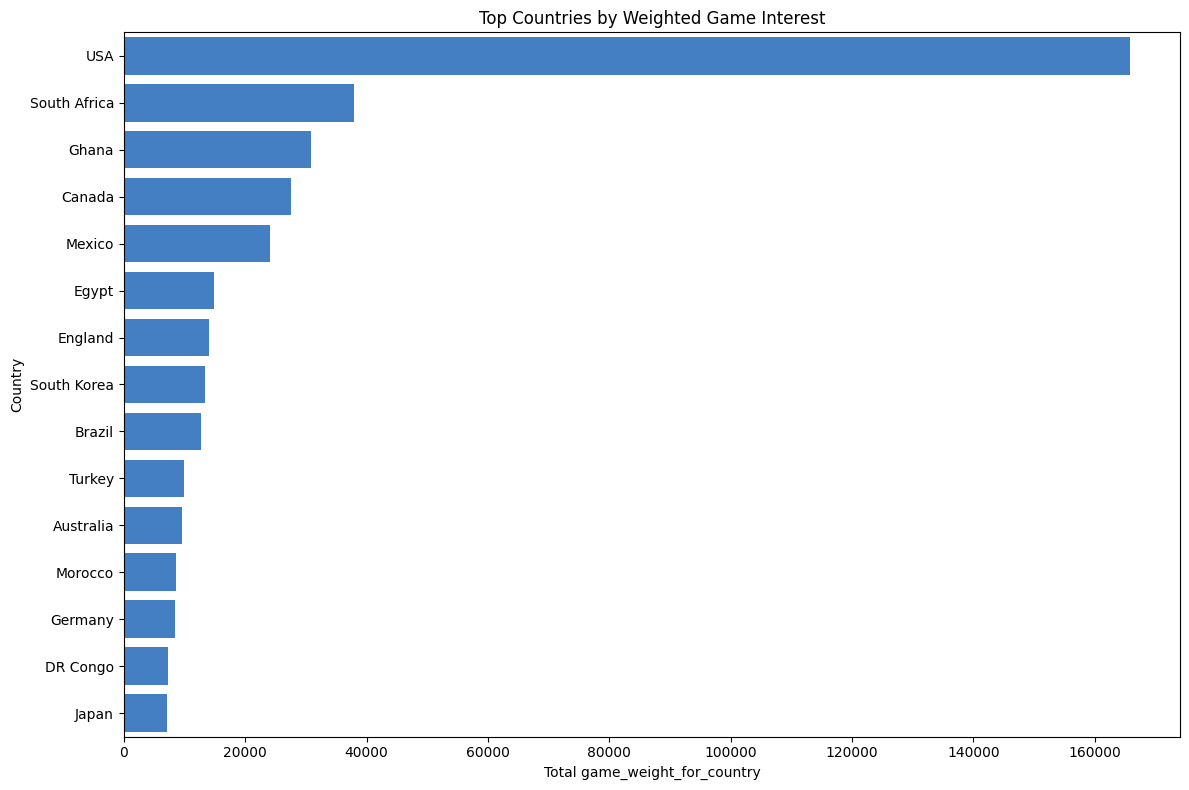

,country_odds,total_weight,avg_localtime,games
45,USA,165757.744399,7.333333,3
38,South Africa,37854.332435,15.333333,3
19,Ghana,30835.554388,21.333333,3
7,Canada,27566.653699,17.000000,3
26,Mexico,24176.214695,19.000000,3
15,Egypt,14804.739211,4.666667,3
16,England,14052.615555,20.666667,3
39,South Korea,13311.226851,12.333333,3
6,Brazil,12747.682490,20.000000,3
44,Turkey,9993.675694,8.333333,3


In [6]:
country_weight = (
    df_weighted_country_game
    .groupby('country_odds', as_index=False)
    .agg(
        total_weight=('game_weight_for_country', 'sum'),
        avg_localtime=('localtime', 'mean'),
        games=('#match', 'count'),
    )
    .sort_values('total_weight', ascending=False)
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=country_weight.head(15),
    y='country_odds',
    x='total_weight',
    color='#2f7ed8',
)
plt.xlabel('Total game_weight_for_country')
plt.ylabel('Country')
plt.title('Top Countries by Weighted Game Interest')
plt.tight_layout()
plt.show()

country_weight.head(15)


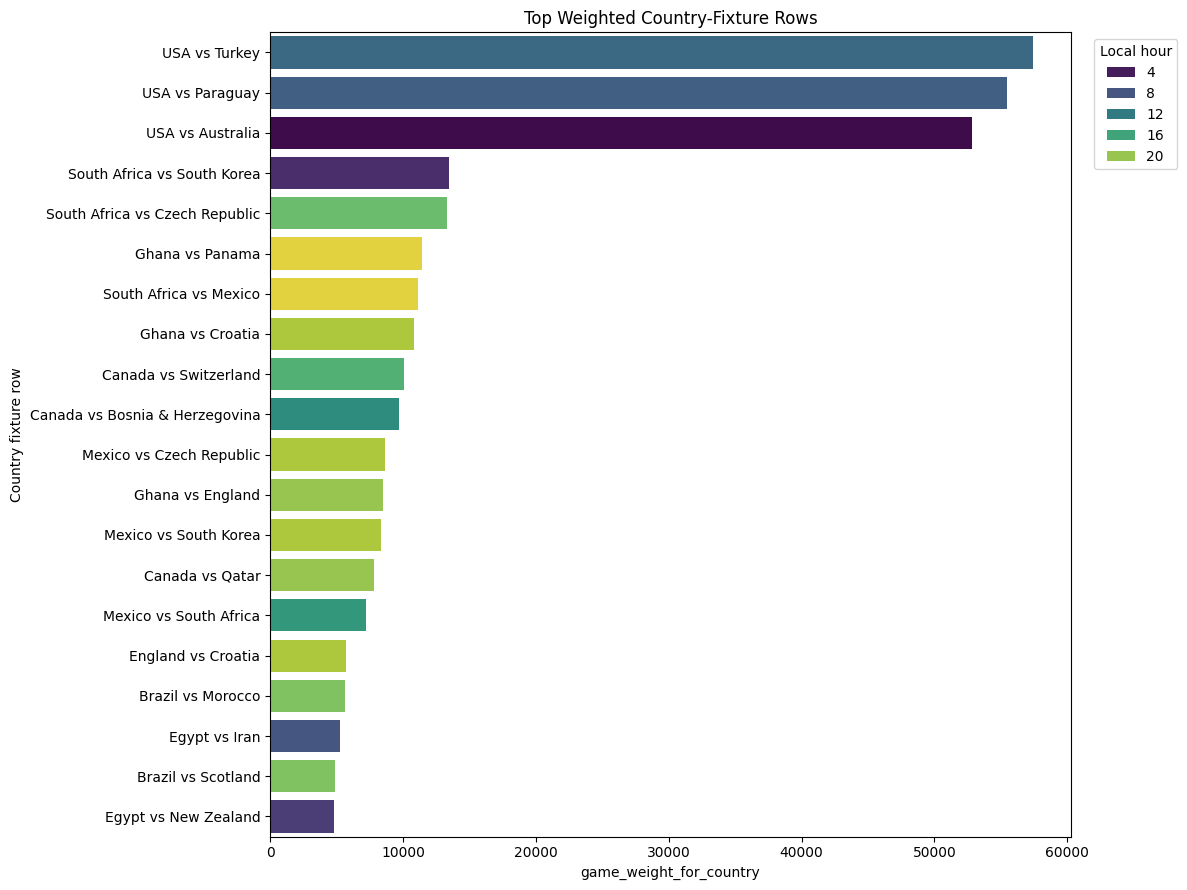

,#match,group,date,local_time,country_odds,opponent_odds,localtime,p_win,closeness,game_weight_for_country
110,59,D,2026-06-25,22.0,USA,Turkey,10.0,0.374976,0.993273,57411.166359
37,4,D,2026-06-12,21.0,USA,Paraguay,9.0,0.476111,0.960063,55491.628649
65,30,D,2026-06-19,15.0,USA,Australia,3.0,0.540678,0.914445,52854.949391
5,54,A,2026-06-24,21.0,South Africa,South Korea,5.0,0.265334,0.973650,13436.363524
72,25,A,2026-06-18,12.0,South Africa,Czech Republic,18.0,0.237954,0.962735,13285.741631
70,23,L,2026-06-17,19.0,Ghana,Panama,23.0,0.469358,0.963898,11470.381033
115,1,A,2026-06-11,15.0,South Africa,Mexico,23.0,0.131304,0.806683,11132.227280
134,68,L,2026-06-27,17.0,Ghana,Croatia,21.0,0.198576,0.912901,10863.525455
82,49,B,2026-06-24,15.0,Canada,Switzerland,17.0,0.256267,0.968480,10072.196378
67,3,B,2026-06-12,15.0,Canada,Bosnia & Herzegovina,14.0,0.519969,0.931012,9682.519736


In [7]:
top_games = df_weighted_country_game.copy()
top_games['fixture_for_country'] = top_games['country_odds'] + ' vs ' + top_games['opponent_odds']
top_games = top_games.sort_values('game_weight_for_country', ascending=False).head(20)

plt.figure(figsize=(12, 9))
sns.barplot(
    data=top_games,
    y='fixture_for_country',
    x='game_weight_for_country',
    hue='local_hour',
    dodge=False,
    palette='viridis',
)
plt.xlabel('game_weight_for_country')
plt.ylabel('Country fixture row')
plt.title('Top Weighted Country-Fixture Rows')
plt.legend(title='Local hour', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

top_games[[
    '#match', 'group', 'date', 'local_time', 'country_odds', 'opponent_odds',
    'localtime', 'p_win', 'closeness', 'game_weight_for_country'
]]


In [8]:
# Optional export for downstream KPI work.
df_weighted_country_game.to_csv(broadcast_dir / 'weighted_country_game_kpis.csv', index=False)


## Local Time Repartition Per Country Weighted by Game Interest

These cells use `game_weight_for_country` from `betting_team_probabilities_with_interest.csv` to show when each country experiences its games in local time.


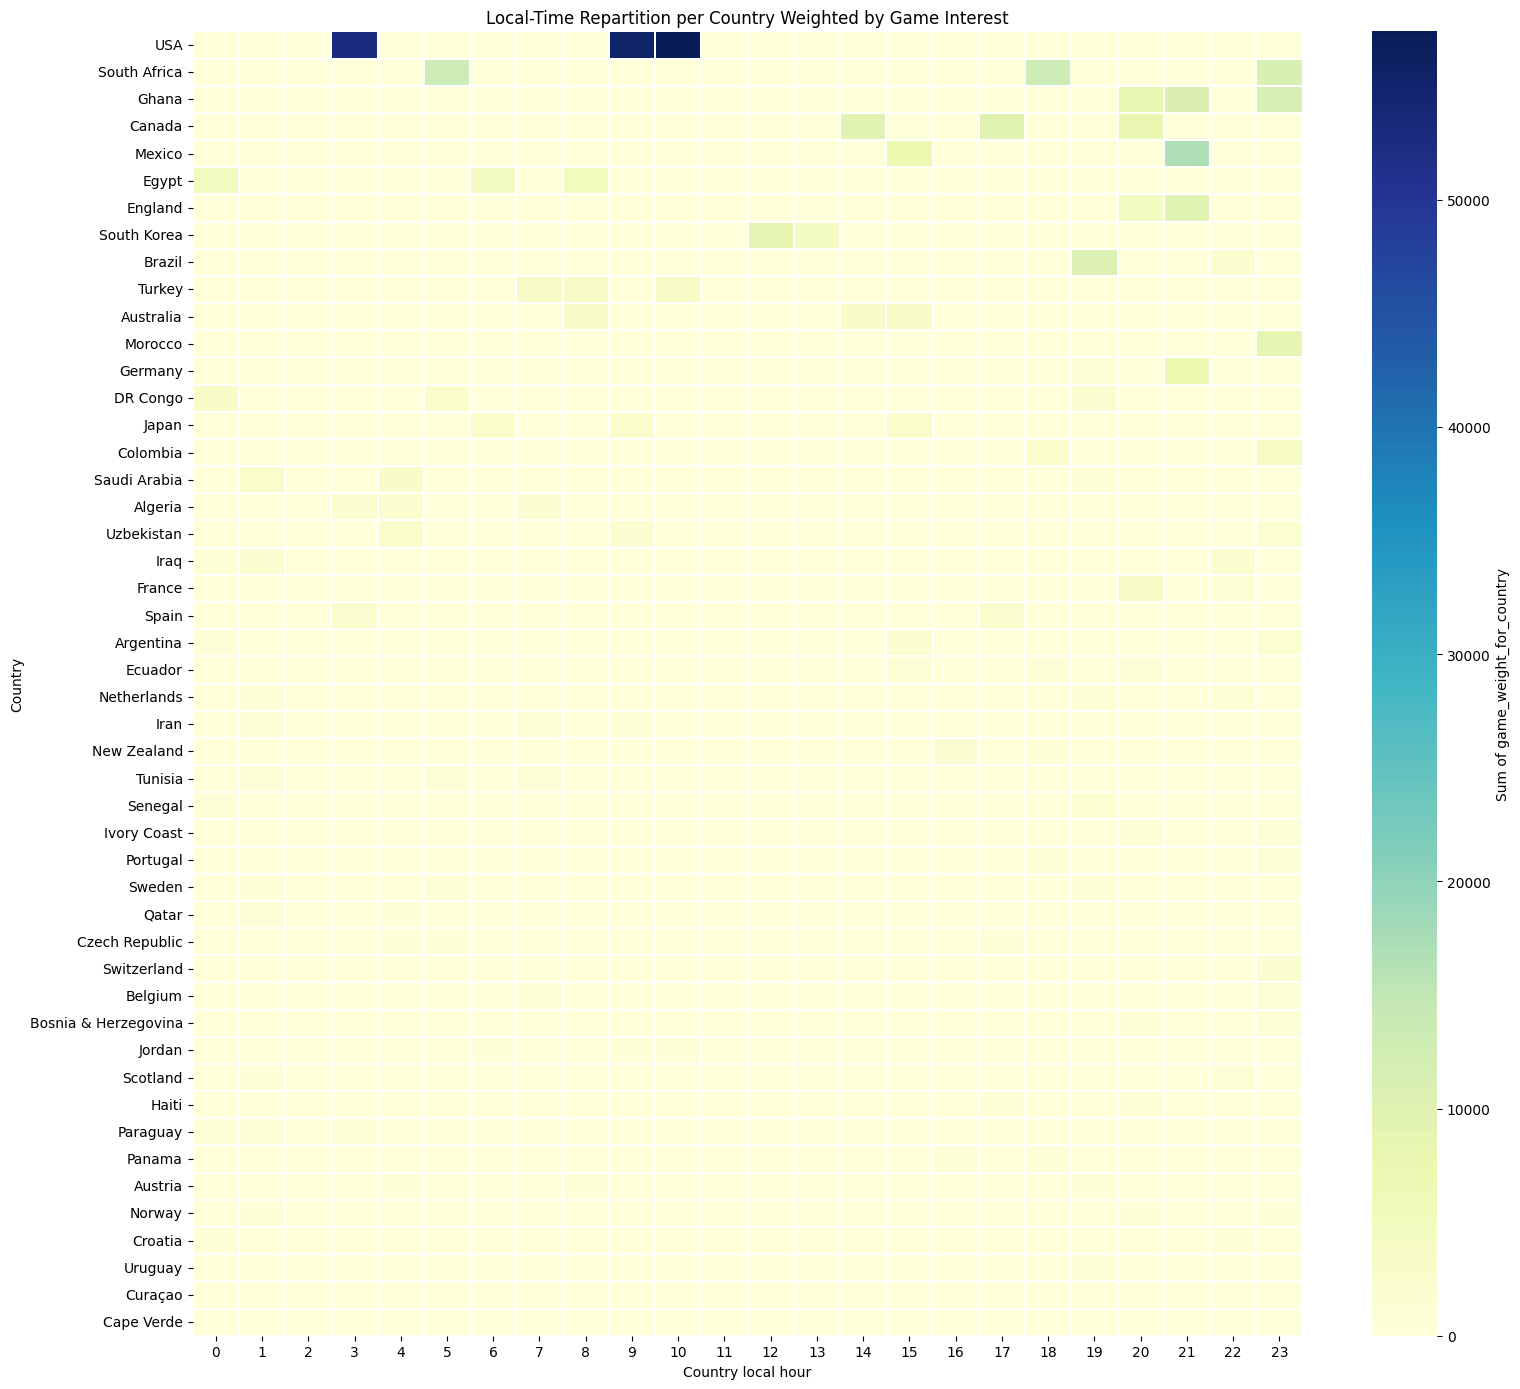

local_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
country_odds,,,,,,,,,,,,,,,,,,,,,
USA,0.000000,0.000000,0,52854.949391,0.000000,0.000000,0.000000,0.000000,0.000000,55491.628649,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
South Africa,0.000000,0.000000,0,0.000000,0.000000,13436.363524,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,13285.741631,0.000000,0.000000,0.000000,0.000000,11132.227280
Ghana,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8501.647901,10863.525455,0.000000,11470.381033
Canada,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9682.519736,0.000000,0.000000,10072.196378,0.000000,0.000000,7811.937585,0.000000,0.000000,0.000000
Mexico,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,7227.880901,0.000000,0.000000,0.000000,0.000000,0.000000,16948.333794,0.000000,0.000000
Egypt,4729.343198,0.000000,0,0.000000,0.000000,0.000000,4809.712991,0.000000,5265.683022,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
England,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4479.439692,9573.175862,0.000000,0.000000
South Korea,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Brazil,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,10544.193396,0.000000,0.000000,2203.489094,0.000000


In [9]:
# Absolute weighted repartition: sum of game_weight_for_country by country and local hour.
df_weighted_country_game['local_hour'] = df_weighted_country_game['localtime'].astype(int)

country_hour_weight = (
    df_weighted_country_game
    .pivot_table(
        index='country_odds',
        columns='local_hour',
        values='game_weight_for_country',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(columns=range(24), fill_value=0)
)

country_order = country_hour_weight.sum(axis=1).sort_values(ascending=False).index
country_hour_weight = country_hour_weight.loc[country_order]

plt.figure(figsize=(16, 14))
sns.heatmap(
    country_hour_weight,
    cmap='YlGnBu',
    linewidths=0.25,
    linecolor='white',
    cbar_kws={'label': 'Sum of game_weight_for_country'},
)
plt.xlabel('Country local hour')
plt.ylabel('Country')
plt.title('Local-Time Repartition per Country Weighted by Game Interest')
plt.tight_layout()
plt.show()

country_hour_weight


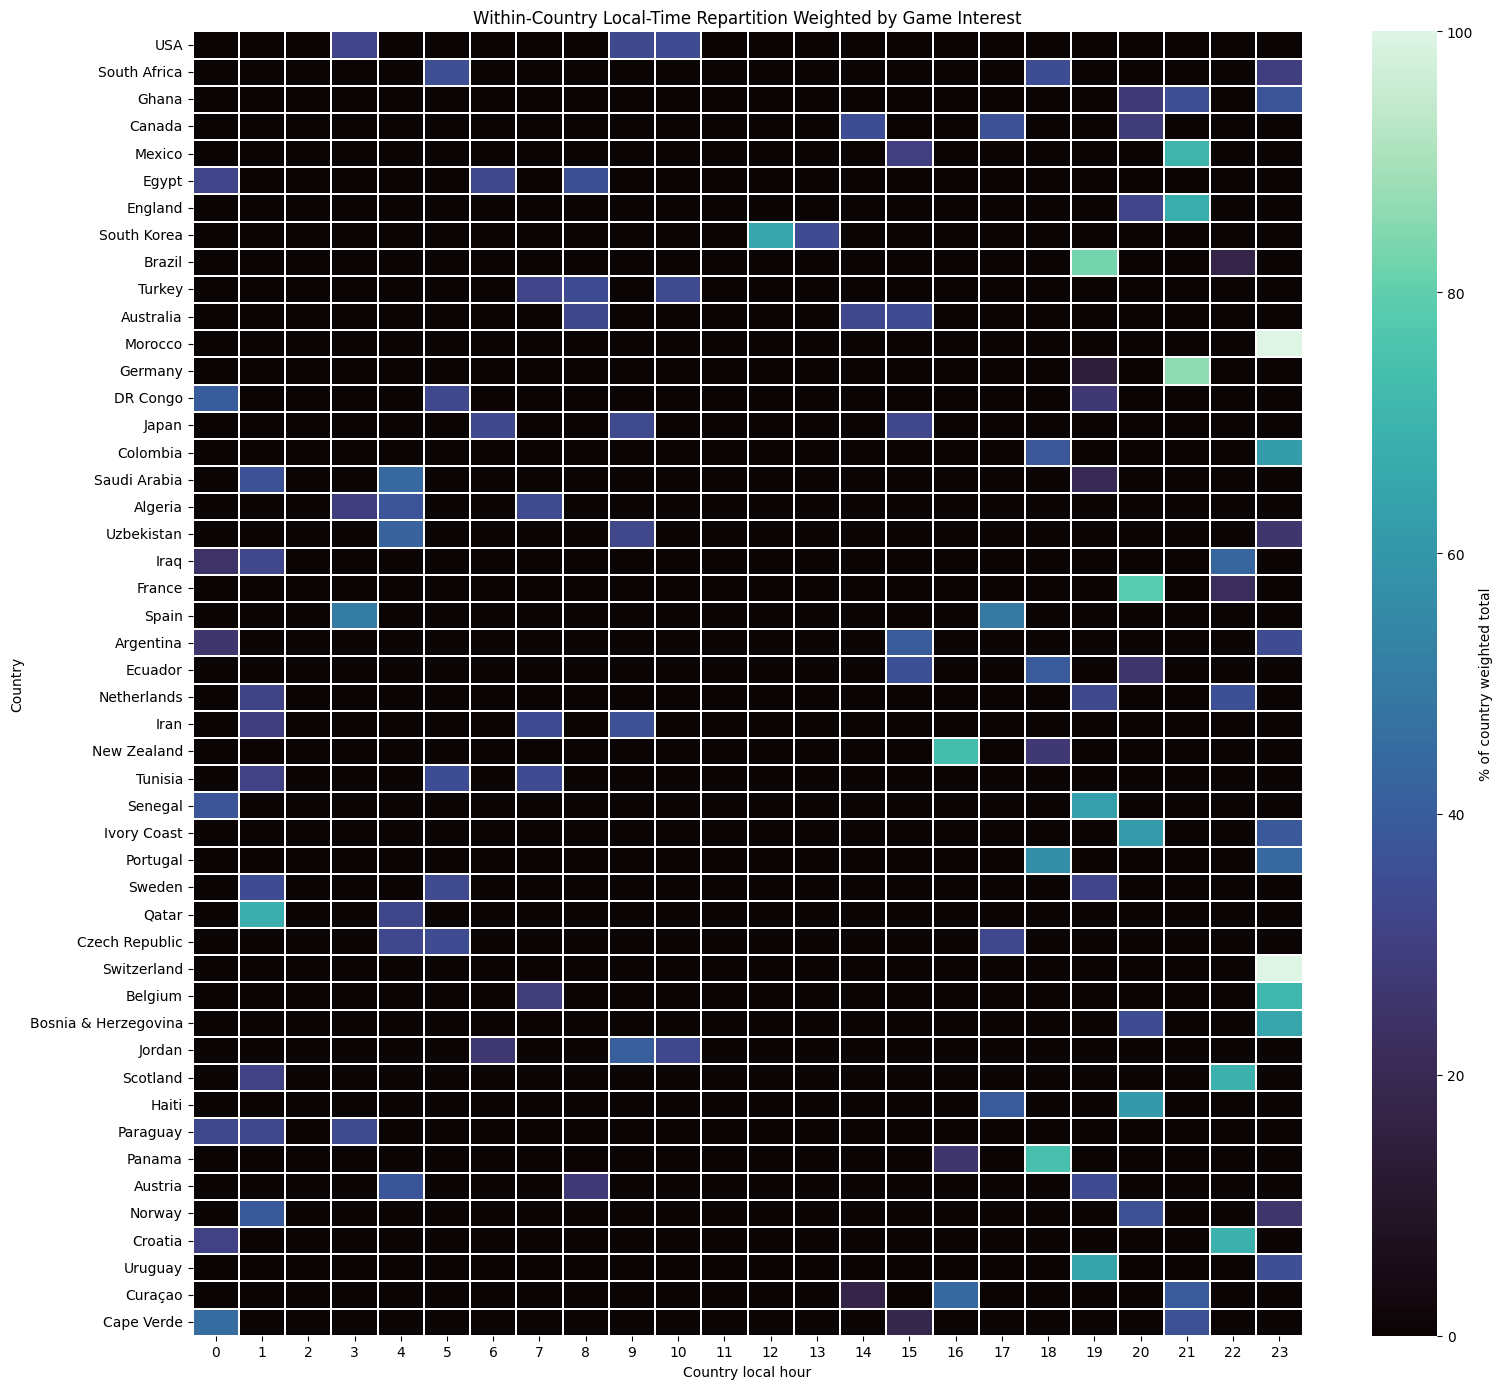

local_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
country_odds,,,,,,,,,,,,,,,,,,,,,
USA,0.000000,0.000000,0.0,31.886866,0.000000,0.000000,0.000000,0.000000,0.000000,33.477548,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
South Africa,0.000000,0.000000,0.0,0.000000,0.000000,35.494916,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,35.097017,0.000000,0.000000,0.000000,0.000000,29.408067
Ghana,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.570926,35.230518,0.000000,37.198556
Canada,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,35.124030,0.000000,0.000000,36.537610,0.000000,0.000000,28.338360,0.000000,0.000000,0.000000
Mexico,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,29.896661,0.000000,0.000000,0.000000,0.000000,0.000000,70.103339,0.000000,0.000000
Egypt,31.944792,0.000000,0.0,0.000000,0.000000,0.000000,32.487658,0.000000,35.567550,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
England,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,31.876199,68.123801,0.000000,0.000000
South Korea,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Brazil,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,82.714591,0.000000,0.000000,17.285409,0.000000


In [10]:
# Normalized weighted repartition: each country row sums to 100%.
country_hour_share = country_hour_weight.div(country_hour_weight.sum(axis=1), axis=0).fillna(0) * 100

plt.figure(figsize=(16, 14))
sns.heatmap(
    country_hour_share,
    cmap='mako',
    linewidths=0.25,
    linecolor='white',
    cbar_kws={'label': '% of country weighted total'},
)
plt.xlabel('Country local hour')
plt.ylabel('Country')
plt.title('Within-Country Local-Time Repartition Weighted by Game Interest')
plt.tight_layout()
plt.show()

country_hour_share
